# Hazard forecasts and impacts forecasts

In this tutorial, we showcase CLIMADA functionality to handle forecast data using the classes `HazardForecast` and `ImpactForecast`.


## Table of Contents

1. [Reading in forecast data](#1-reading-in-forecast-data)
   - 1.1 [Using MeteoSwiss Open Government Data weather forecasts](#11-using-meteoswiss-open-government-data-weather-forecasts)
   - 1.2 [Using CLIMADA API demo data](#12-using-climada-api-demo-data)
2. [Impact calculation](#2-impact-calculation)
3. [Forecast products based on ImpactForecast](#3-forecast-products-based-on-impactforecast)
4. [Download and save data from MeteoSwiss Open Government Data](#download-and-save-data-from-meteoswiss-open-government-data)

In [1]:
# import necessary packages
import xarray as xr
import numpy as np

# import numbers
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

admin1 = cfeature.NaturalEarthFeature(
    category="cultural", name="admin_1_states_provinces_lines", scale="10m"
)
lakes = cfeature.LAKES.with_scale("10m")
borders = cfeature.BORDERS.with_scale("10m")

from climada.util.config import CONFIG
from climada.entity import ImpactFunc, ImpactFuncSet

from climada.hazard.forecast import HazardForecast
from climada.engine import ImpactCalc, ImpactForecast

from climada.entity.exposures.litpop import LitPop


## 1. Reading in forecast data


### 1.1 Using MeteoSwiss Open Government Data weather forecasts

This example retrieves the latest OGD forecast data from MeteoSwiss.
You can also skip this step and go to section 1.2 for using stored demo data from the CLIMADA API.

Requires the package `meteodata-lab`, available via `pip`.

You can find out all about data openly published here (info and notebooks on how to retrieve):

Check out:
* https://github.com/MeteoSwiss/meteodata-lab and
* https://github.com/MeteoSwiss/opendata-nwp-demos/blob/main/01_retrieve_process_precip.ipynb
* https://www.meteoschweiz.admin.ch/service-und-publikationen/service/open-data.html



In [2]:
# optional packages for this section only
from meteodatalab import ogd_api
from meteodatalab.operators import time_operators as time_ops
from earthkit.data import config

config.set("cache-policy", "temporary")

earthkit-data cache: trying to free 4.6 GiB
earthkit-data cache: could not free 4.6 GiB


In [3]:
# Define target lead times for ICON-CH2-EPS: up 5d, here +0h, to +12h
lead_times = [f"P0DT{i}H" for i in np.arange(0, 13)]
model = "ogd-forecasting-icon-ch2"
nwp_vars = ["TOT_PREC", "VMAX_10M"]  # precip. and wind; temperature: "T_2M"
reftime = "latest"  # also try: 'latest'

In [4]:
dict_ens_data = {}
for var in nwp_vars:
    req = ogd_api.Request(
        collection=model,
        variable=var,
        ref_time=reftime,
        perturbed=True,  # ensembles
        lead_time=lead_times,
    )
    dict_ens_data[var] = ogd_api.get_from_ogd(req)

dict_ens_data["TOT_PREC"] = time_ops.delta(
    dict_ens_data["TOT_PREC"], np.timedelta64(1, "h")
)

earthkit-data cache: trying to free 4.6 GiB
earthkit-data cache: could not free 4.6 GiB
earthkit-data cache: trying to free 4.6 GiB                                                                                                                            
Deleting entry {
    "path": "/var/folders/04/tbpkdd855mg6mjr2mj6h1csh0000gp/T/tmp32u70oe2/url-2aa003b210e62565c801ebb3efa5b014e590c207bdf1435214f45b9b7c6354f4.unknown",
    "owner": "url",
    "args": {
        "url": [
            "https://rgw.cscs.ch/cscs.meteoswiss.ogd.nwp/icon-ch2-eps-202512111200-0-tot_prec-perturb.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=5lzlIMJjMH3F8IozUtXR7IA%2B3ds%3D&Expires=1765547840",
            "https://rgw.cscs.ch/cscs.meteoswiss.ogd.nwp/icon-ch2-eps-202512111200-1-tot_prec-perturb.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=v%2FRcw3zRqE%2FWJ4i3MN1wMaACiQE%3D&Expires=1765548066",
            "https://rgw.cscs.ch/cscs.meteoswiss.ogd.nwp/icon-ch2-eps-202512111200-2-tot_prec-perturb.gri

In [5]:
ds_icon_latest = xr.Dataset(dict_ens_data)
init_time_str = np.datetime_as_string(ds_icon_latest.ref_time.values[0], unit="h")

In [6]:
haz_fc_icon_latest = HazardForecast.from_xarray_raster(
    ds_icon_latest,
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "lon",
        "latitude": "lat",
        "lead_time": "lead_time",
        "member": "eps",
    },
    intensity="TOT_PREC",
)

2025-12-11 17:26:08,874 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2025-12-11 17:26:08,877 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


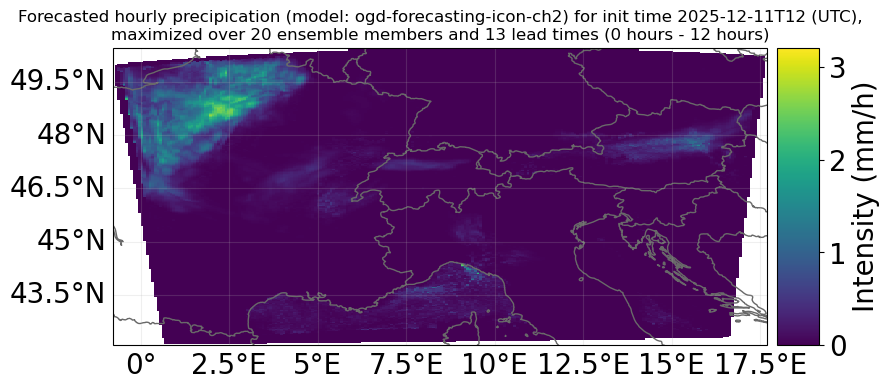

In [7]:
# plot whether there is precipitation in the forecast
ax = haz_fc_icon_latest.plot_intensity(event=0)
lead_times = np.unique(haz_fc_icon_latest.lead_time).astype("timedelta64[h]")
ax.set_title(
    f"Forecasted hourly precipication (model: {model}) for init time {init_time_str} (UTC),\n"
    f"maximized over {len(np.unique(haz_fc_icon_latest.member))} ensemble members and {len(lead_times)} lead times ({lead_times[0]} - {lead_times[-1]})"
);

### 1.2 Using CLIMADA API demo data

As an example, we load existing forecast data for an event including heavy precipitation and flooding on June 21, 2024 in in Misox, Switzerland.

After loading the data as a netcdf file, we read it into a `HazardForecast` object.

In [8]:
# temporary local path
# TODO adapt to data on CLIMADA API
path_to_forecast_nc = "/Users/vgebhart/Documents/climada/data/forecast/hazard/fcst_icon_seamless_2024-06-18_12_00.nc"

In [9]:
hazard_forecast = HazardForecast.from_xarray_raster(
    path_to_forecast_nc,
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "x",
        "latitude": "y",
        "lead_time": "lead_time",
        "member": "realization",
    },
    intensity="precipitation_amount_1hsum",
    crs="EPSG:2056",
)
# transform to EPSG:4326
hazard_forecast.centroids.gdf = hazard_forecast.centroids.gdf.to_crs(epsg=4326)

/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/hazard/forecast.py:454: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dset = xr.open_dataset(data, **open_dataset_kws)


2025-12-11 17:26:24,074 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2025-12-11 17:26:24,076 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


`HazardForecast` objects include forecasts produced at a specific init time, but for several several lead times and several forecast ensemble members. For this, it includes the two array-like attributes
- `member` to indicate the forecast ensemble member, and
- `lead_time` to indicate the lead time of the data,

both of which can be used to select specific forecasts.

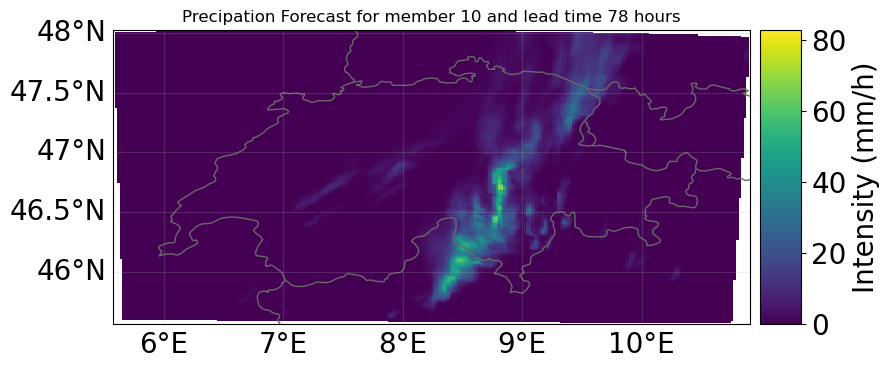

In [10]:
# select hazard forecast for a specific member and a specific lead time
test_member = 10
test_lead_time = np.timedelta64(78, "h")
ax = hazard_forecast.select(
    member=test_member,
    lead_time=test_lead_time,
).plot_intensity(0)
ax.set_title(
    f"Precipation Forecast for member {test_member} and lead time {test_lead_time.astype('timedelta64[h]')}"
);

The two forecast attributes `member` and `lead_time` can be used to generate (centroid-wise) statistics by means of methods like, e.g.,
- `.max(dim="lead_time")` to compute the maximum hazard intensity over the lead times, for each member and centroid,
- `.quantile(q=.3, dim="member")` to compute the 0.3-quantile of the hazard intensity over the members, for each lead time and centroid, or
- `.mean()` to compute the mean of the hazard intensity over all lead times and members, for each centroid.

In [12]:
# plot median over member dimension for given a lead time
# TODO uncomment this code block and check if runs through
# ax = (
#     hazard_forecast.median(dim="member")
#     .select(lead_time=test_lead_time)
#     .plot_intensity(0)
# )
# ax.set_title(
#     f"Hazard Forecast for member {hazard_forecast.member[id_member]} and lead time {hazard_forecast.lead_time[id_lead_time]}"
# );

`HazardForecast` objects can be written to and read from hdf5 files:

In [13]:
# # write hazard forecast object to h5 file
# DATA_DIR = Path(CONFIG.local_data.data_dir.str())
# data_dir_hazard_forecast = DATA_DIR / "forecast" / "hazard"
# hazard_forecast.write_hdf5(data_dir_hazard_forecast / "demo_hazard_forecast.h5")

# # read hazard forecast from h5 file
# hazard_forecast_read = HazardForecast.from_hdf5(data_dir_hazard_forecast / "demo_hazard_forecast.h5")

## 2. Impact calculation

`HazardForecast` objects can be handed in to the standard CLIMADA ImpactCalc engine to produce `ImpactForecast` objects, consisting of one impact forecast in `ImpactForecast` corresponding to each hazard forecast in `HazardForecast`.

We exemplify this below by loading a population exposure layer for Switzerland and Liechtenstein, and by defining a step impact function. This impact function results in impacts describing how much population (how many people) are exposed to a precipitation of more than 50mm/h.

2025-12-11 17:27:25,560 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: CHE (756)...

2025-12-11 17:27:25,920 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: LIE (438)...

2025-12-11 17:27:25,987 - climada.entity.exposures.base - INFO - Hazard type not set in impf_
2025-12-11 17:27:25,988 - climada.entity.exposures.base - INFO - category_id not set.
2025-12-11 17:27:25,988 - climada.entity.exposures.base - INFO - cover not set.
2025-12-11 17:27:25,989 - climada.entity.exposures.base - INFO - deductible not set.
2025-12-11 17:27:25,989 - climada.entity.exposures.base - INFO - centr_ not set.
2025-12-11 17:27:25,990 - climada.entity.exposures.base - INFO - Matching 70525 exposures with 27000 centroids.
2025-12-11 17:27:26,051 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100 degree


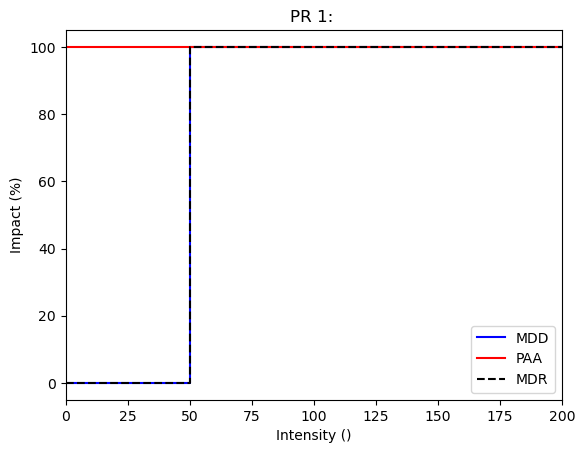

In [14]:
# Read exposure for population
exp_che = LitPop.from_population(countries=["CHE", "LIE"], res_arcsec=30)
# Assign centroids because hazard not on regular grid
exp_che.assign_centroids(hazard_forecast, threshold=100)

# define impact functions
threshold_for_affected = 50
imp_fun_precip = ImpactFunc.from_step_impf(
    (0, threshold_for_affected, 200), haz_type=f"PR", impf_id=1
)
impf_set = ImpactFuncSet([imp_fun_precip])
impf_set.plot();

In [15]:
# calculate impact
impact_forecast = ImpactCalc(exp_che, impf_set, hazard_forecast).impact(
    assign_centroids=False,  # assign_centroid=False because we do not want to reassign centroids
)  # impact matrix is saved by default

2025-12-11 17:27:26,189 - climada.entity.exposures.base - INFO - No specific impact function column found for hazard PR. Using the anonymous 'impf_' column.
2025-12-11 17:27:26,192 - climada.engine.impact_calc - INFO - Calculating impact for 208182 assets (>0) and 2415 events.
2025-12-11 17:27:26,477 - climada.engine.impact_calc - WARNING - eai_exp and aai_agg are undefined with forecasts. Setting them to NaN arrays.
2025-12-11 17:27:26,490 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2025-12-11 17:27:26,490 - climada.engine.impact_forecast - WARNING - at_event gives the total impact for one specific combination of member and lead_time.


## 3. Forecast products based on ImpactForecast

We can now analyse the impact forecasts by selecting specific ensemble member or lead times (or other impact attributes), or by computing statistics (min, max, quantile, mean) over the forecast dimensions `member` and `lead_time`.

For the specific case of Misox, we will zoom in to the canton of Ticino.

2025-12-11 17:27:26,604 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.


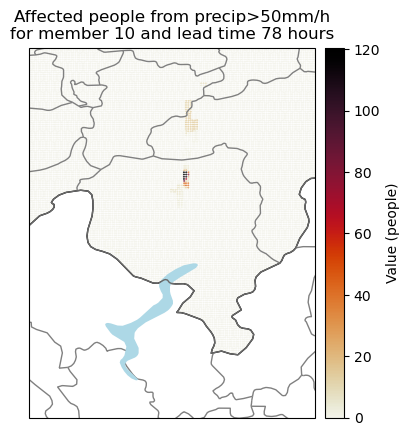

In [16]:
# select hazard forecast for a specific member and a specific lead time and plot Ticino extent

impact_forecast_sel = impact_forecast.select(
    member=test_member,
    lead_time=test_lead_time,
)
extent_ticino = [8.2, 9.3, 45.58, 47]

fig = plt.figure(figsize=(6, 4))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(borders, linewidth=1)
ax.add_feature(admin1, edgecolor="gray", linewidth=1.0, facecolor="none")
ax.add_feature(lakes, facecolor="lightblue")

# plot impact forecast
impact_forecast_sel.plot_hexbin_impact_exposure(
    event_id=impact_forecast_sel.event_id, pop_name=False, axis=ax
)
ax.set_extent(extent_ticino)
ax.set_title(
    f"Affected people from precip>{threshold_for_affected}mm/h\nfor member {test_member} and lead time {test_lead_time.astype('timedelta64[h]')}"
);

2025-12-11 17:27:31,033 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.


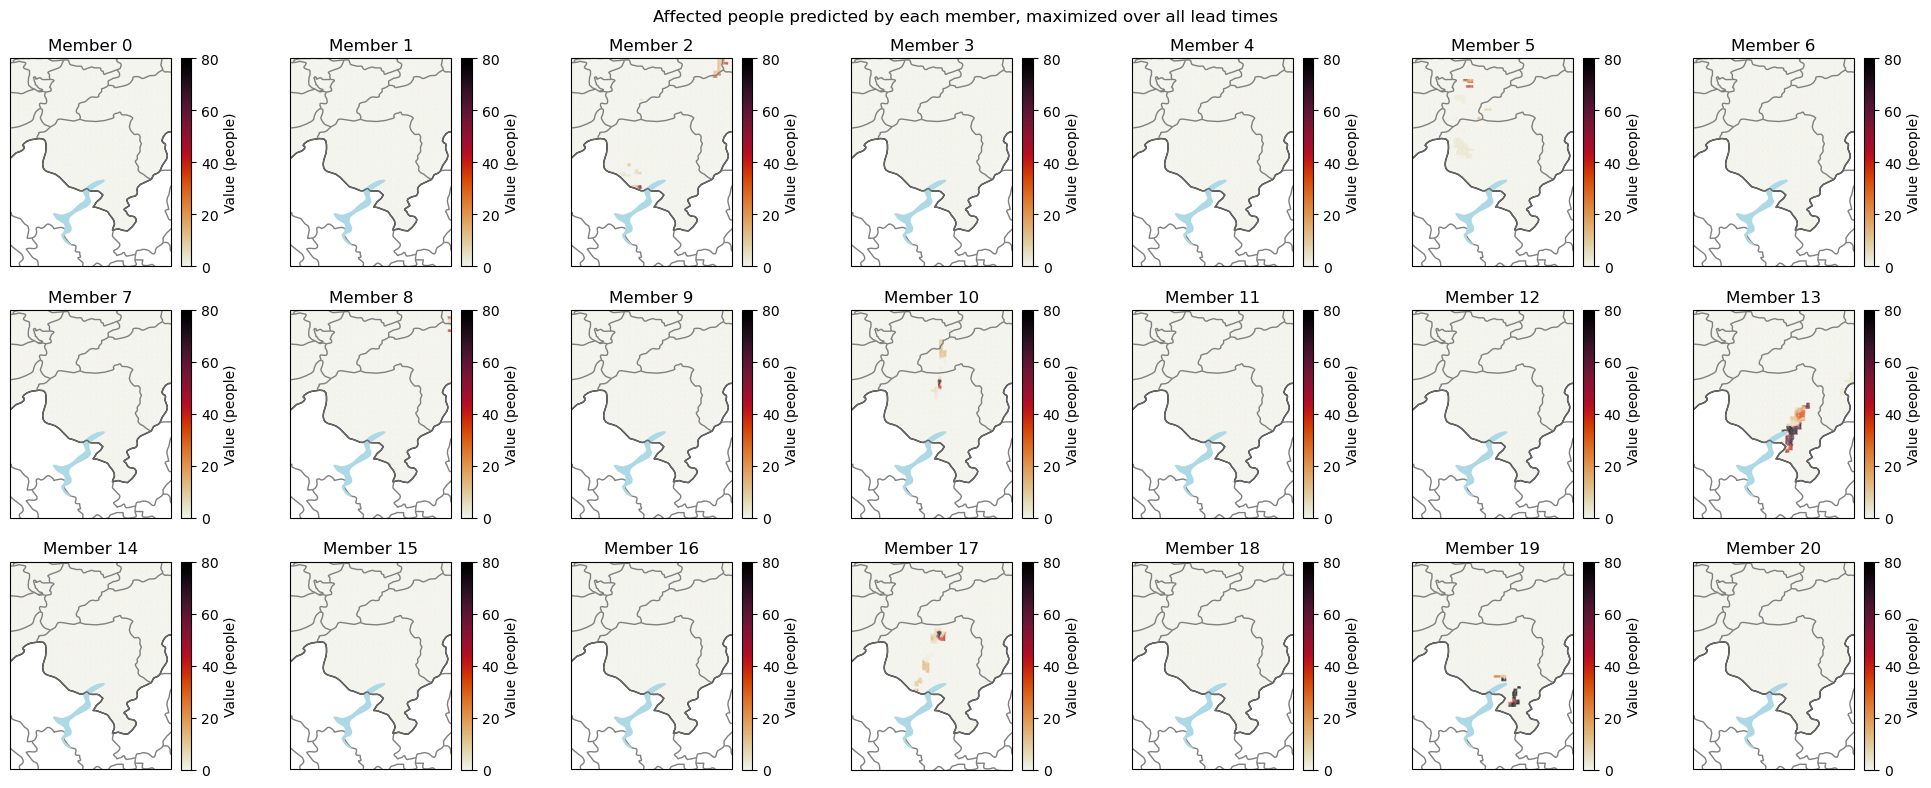

In [17]:
# per member map of maximum precip over leatimes
# TODO use this line:
# max_impact_per_member = impact_forecast.max(dim="lead_time")
# TODO remove these two lines
imp_fct_sel = impact_forecast.select(lead_time=test_lead_time)
max_impact_per_member = imp_fct_sel

fig, ax = plt.subplots(
    3, 7, figsize=(20, 8), subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.suptitle("Affected people predicted by each member, maximized over all lead times")
ax = ax.flatten()
for j, member in enumerate(max_impact_per_member.member):
    ax[j].add_feature(borders, linewidth=1)
    ax[j].add_feature(admin1, edgecolor="gray", linewidth=1.0, facecolor="none")
    ax[j].add_feature(lakes, facecolor="lightblue")

    # plot impact forecast
    max_impact_per_member.plot_hexbin_impact_exposure(
        event_id=max_impact_per_member.event_id[j],
        pop_name=False,
        axis=ax[j],
        vmin=0,
        vmax=80,
    )
    ax[j].set_extent(extent_ticino)
    ax[j].set_title(f"Member {j}")

Next, we can analyse the evolution of predicted number of affected people over Switzerland (member distribution shown as a histogram) with increasing forecast lead time.

2025-12-11 17:28:27,405 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-11 17:28:27,409 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-11 17:28:27,413 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-11 17:28:27,417 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-11 17:28:27,421 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2025-12-11 17:28:27,426 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the

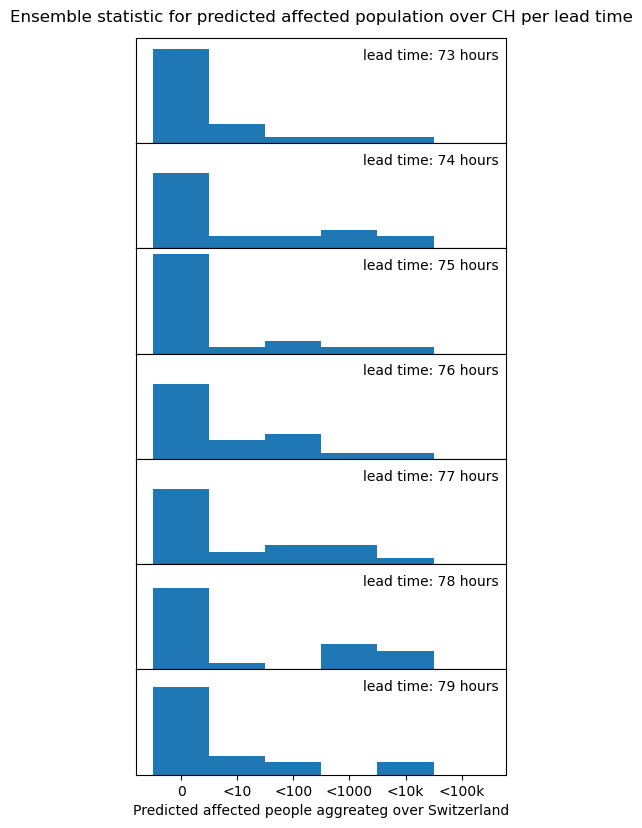

In [18]:
lead_time_window = np.timedelta64(1, "h") * np.arange(73, 80)
n_lead_times = len(lead_time_window)

fig, ax = plt.subplots(
    nrows=n_lead_times,
    ncols=1,
    figsize=(4, 1.2 * n_lead_times),
    sharex=True,
    sharey=True,
)
ax = ax.flatten()
log_histogram_bins = np.arange(7)

for j, lead_time in enumerate(lead_time_window):
    imp_for_per_lt = impact_forecast.select(lead_time=lead_time)
    imp_per_member = imp_for_per_lt.imp_mat.sum(axis=1)
    ax[j].hist(np.log10(imp_per_member + 1), bins=log_histogram_bins, alpha=1)
    ax[j].set_yticks([])
    ax[j].text(
        0.98,
        0.90,
        f"lead time: {lead_time.astype('timedelta64[h]')}",
        ha="right",
        va="top",
        transform=ax[j].transAxes,
    )

ax[-1].set_xlabel("Predicted affected people aggreateg over Switzerland")

bin_centers = 0.5 * (log_histogram_bins[:-1] + log_histogram_bins[1:])
ax[-1].set_xticks(bin_centers)
ax[-1].set_xticklabels(["0", "<10", "<100", "<1000", "<10k", "<100k"])

plt.suptitle(
    "Ensemble statistic for predicted affected population over CH per lead time"
)
plt.tight_layout()
plt.subplots_adjust(hspace=0)

Attributes of an `ImpactForecast` object that do not make sense if impacts correspond to different ensemble members and lead times (instead of impacts of different events in a probabilistic event set as usual in `Impact` objects) are filled with NaNs.

In [19]:
print("average annual imact: ", impact_forecast.aai_agg)
print("average annual impact per centroid: ", impact_forecast.eai_exp)
try:
    impact_forecast.calc_freq_curve()
except NotImplementedError as e:
    print(e)

average annual imact:  nan
average annual impact per centroid:  [nan nan nan ... nan nan nan]
2025-12-11 17:28:27,556 - climada.engine.impact_forecast - ERROR - calc_freq_curve is not defined for ImpactForecast
calc_freq_curve is not defined for ImpactForecast


`ImpactForecast` objects can be written to and read from hdf5 files:

In [21]:
# write hazard forecast object to h5 file
DATA_DIR = Path(CONFIG.local_data.data_dir.str())
data_dir_impact_forecast = DATA_DIR / "forecast" / "impact"
data_dir_impact_forecast.mkdir(exist_ok=True)
impact_forecast.write_hdf5(data_dir_impact_forecast / "demo_impact_forecast.h5")

# read hazard forecast from h5 file
imp_fct = ImpactForecast.from_hdf5(data_dir_impact_forecast / "demo_impact_forecast.h5")

TypeError: iteration over a 0-d array